# Fake News Detection System
<ol start="0">
<li> Data Collection </li>
<li> Data Visualization</li>
<li> Data Cleaning & Feature Engineering </li>
<li> Data Transformation  </li>
<li> Modeling</li>
</ol>

### Data Collection

In [21]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import re
import string
import unicodedata
import seaborn as sns


In [22]:
df_test = pd.read_csv('dataset/test.tsv', sep='\t',header=None)
df_train = pd.read_csv('dataset/train.tsv', sep='\t',header=None)
df_validation = pd.read_csv('dataset/valid.tsv', sep='\t',header=None)

df_test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1262,7334.json,half-true,Says his budget provides the highest state fun...,education,rick-scott,Governor,Florida,republican,28,23,38,34,7,a news conference
1263,9788.json,barely-true,Ive been here almost every day.,"civil-rights,crime,criminal-justice",jay-nixon,Governor,Missouri,democrat,2,0,0,1,0,"on ABC's ""This Week"""
1264,10710.json,barely-true,"In the early 1980s, Sen. Edward Kennedy secret...","bipartisanship,congress,foreign-policy,history",mackubin-thomas-owens,"senior fellow, Foreign Policy Research Institute",Rhode Island,columnist,1,0,0,0,0,a commentary in The Providence Journal
1265,3186.json,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",john-kasich,"Governor of Ohio as of Jan. 10, 2011",Ohio,republican,9,8,10,18,3,a news conference


In [23]:
dataset_description = "A BENCHMARK DATASET FOR FAKE NEWS DETECTION"
dataset_source = "LIAR dataset from https://www.cs.ucsb.edu/~william/data/liar_dataset.zip"

In [24]:
columns = pd.Series([
    'Id',
    'Label',
    'Statement',
    'Subject',
    'Speaker',
    'Speaker Job Title',
    'State Info',
    'Party Affiliation',
    'Barely True Counts',
    'False Counts',
    'Half True Counts',
    'Mostly True Counts',
    'Pants on Fire Counts',
    'Context',

])

In [25]:
df_test.columns = columns
df_train.columns = columns
df_validation.columns = columns


In [26]:
def describe_dataset(df, name):
    print("The dataset is divided into three parts: training, validation, and test sets.")
    print(f"Dataset source {dataset_source}")
    print(f"{name} set:")
    print(f"Number of samples: {len(df)}")

describe_dataset(df_test,'test')

The dataset is divided into three parts: training, validation, and test sets.
Dataset source LIAR dataset from https://www.cs.ucsb.edu/~william/data/liar_dataset.zip
test set:
Number of samples: 1267


In [27]:
def format(df,name): 
    print(f"\n{name} set:")
    print(df.head())
    print(f'df.shape: {df.shape}')
    print("\nStatistical summary:")
    print(df.describe(include='all'))

In [28]:
def understand_data(df,name):
    print(f"\n{name} set:")
    print("Columns and their data types:")
    print(columns)
    print(df.isnull().sum())


In [29]:
describe_dataset(df_train,"Training")

The dataset is divided into three parts: training, validation, and test sets.
Dataset source LIAR dataset from https://www.cs.ucsb.edu/~william/data/liar_dataset.zip
Training set:
Number of samples: 10240


In [30]:
format(df_train,"Training")


Training set:
           Id        Label                                          Statement  \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                              Subject         Speaker     Speaker Job Title  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

  State Info Party Affi

In [31]:
understand_data(df_train,"Training")


Training set:
Columns and their data types:
0                       Id
1                    Label
2                Statement
3                  Subject
4                  Speaker
5        Speaker Job Title
6               State Info
7        Party Affiliation
8       Barely True Counts
9             False Counts
10        Half True Counts
11      Mostly True Counts
12    Pants on Fire Counts
13                 Context
dtype: object
Id                         0
Label                      0
Statement                  0
Subject                    2
Speaker                    2
Speaker Job Title       2898
State Info              2210
Party Affiliation          2
Barely True Counts         2
False Counts               2
Half True Counts           2
Mostly True Counts         2
Pants on Fire Counts       2
Context                  102
dtype: int64


In [32]:
def merge_datasets(df1, df2, df3):
    merged_df = pd.concat([df1, df2, df3], ignore_index=True)
    return merged_df

merged_df = merge_datasets(df_train, df_validation, df_test)


In [33]:
print("Merged Dataset:")
print(merged_df.shape)


Merged Dataset:
(12791, 14)


In [34]:
def overview_merged_dataset(merged_df):
    print("Merged Dataset Overview:")
    print(merged_df.head())
    print(f"Merged dataset shape: {merged_df.shape}") #(12791, 14)
    print("Infos about the columns : ")
    print(merged_df.info())

In [35]:
overview_merged_dataset(merged_df)

Merged Dataset Overview:
           Id        Label                                          Statement  \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                              Subject         Speaker     Speaker Job Title  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

  State Info 

In [36]:
#calculating null values in each column
def null_values_summary(merged_df):
    print("\nNull values in each column:")
    print(merged_df.isnull().sum())

In [37]:
null_values_summary(merged_df)


Null values in each column:
Id                         0
Label                      0
Statement                  0
Subject                    2
Speaker                    2
Speaker Job Title       3568
State Info              2751
Party Affiliation          2
Barely True Counts         2
False Counts               2
Half True Counts           2
Mostly True Counts         2
Pants on Fire Counts       2
Context                  131
dtype: int64


In [38]:
def understand_columns_values(merged_df,column_name):
    print(f"\nUnique values for the column {column_name}:")
    print(merged_df[column_name].value_counts())

#loop through all cols
# for col in merged_df.columns:
#     understand_columns_values(merged_df, col)

In [39]:
for col in merged_df.columns:
     understand_columns_values(merged_df, col)


Unique values for the column Id:
Id
6743.json     1
2635.json     1
10540.json    1
324.json      1
1123.json     1
             ..
4148.json     1
7115.json     1
9741.json     1
5602.json     1
153.json      1
Name: count, Length: 12791, dtype: int64

Unique values for the column Label:
Label
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047
Name: count, dtype: int64

Unique values for the column Statement:
Statement
On changing the rules for filibusters on presidential nominees                                                                                                                                                 3
On a cap-and-trade plan.                                                                                                                                                                                       3
During Sherrod Browns past decade as a D.C. politician, more than one out of every four 

In [40]:
def identify_null_values(df,col_name):
    filt = df[col_name].isnull() == True
    print(f"\nRows with null values in column {col_name}:")
    print(df.loc[filt,['Id',col_name]])


In [41]:
for col in merged_df.columns:
     identify_null_values(merged_df, col)


Rows with null values in column Id:
Empty DataFrame
Columns: [Id, Id]
Index: []

Rows with null values in column Label:
Empty DataFrame
Columns: [Id, Label]
Index: []

Rows with null values in column Statement:
Empty DataFrame
Columns: [Id, Statement]
Index: []

Rows with null values in column Subject:
             Id Subject
2142   638.json     NaN
9375  1626.json     NaN

Rows with null values in column Speaker:
             Id Speaker
2142   638.json     NaN
9375  1626.json     NaN

Rows with null values in column Speaker Job Title:
              Id Speaker Job Title
3      1123.json               NaN
4      9028.json               NaN
6      2342.json               NaN
8      5602.json               NaN
13     8616.json               NaN
...          ...               ...
12777  9241.json               NaN
12781  1005.json               NaN
12784  5671.json               NaN
12785  6699.json               NaN
12790  6743.json               NaN

[3568 rows x 2 columns]

Rows with n

In [42]:
#identify float columns 

def float_columns_summary(merged_df):
    float_cols = merged_df.select_dtypes(include=['float64']).columns
    print("\nFloat columns summary:")
    for col in float_cols:
        print(f"{col}:")
        print(merged_df[col].describe())
        print("Missing values :")
        identify_null_values(merged_df, col)
# for col in merged_df.select_dtypes(include=['float64']).columns:
#     identify_null_values(merged_df, col)

# float_columns_summary(merged_df)
# null_values_summary(merged_df)

In [43]:
for col in merged_df.select_dtypes(include=['float64']).columns:
     identify_null_values(merged_df, col)


Rows with null values in column Barely True Counts:
             Id  Barely True Counts
2142   638.json                 NaN
9375  1626.json                 NaN

Rows with null values in column False Counts:
             Id  False Counts
2142   638.json           NaN
9375  1626.json           NaN

Rows with null values in column Half True Counts:
             Id  Half True Counts
2142   638.json               NaN
9375  1626.json               NaN

Rows with null values in column Mostly True Counts:
             Id  Mostly True Counts
2142   638.json                 NaN
9375  1626.json                 NaN

Rows with null values in column Pants on Fire Counts:
             Id  Pants on Fire Counts
2142   638.json                   NaN
9375  1626.json                   NaN


In [44]:
float_columns_summary(merged_df)


Float columns summary:
Barely True Counts:
count    12789.000000
mean        11.583939
std         18.978037
min          0.000000
25%          0.000000
50%          2.000000
75%         12.000000
max         70.000000
Name: Barely True Counts, dtype: float64
Missing values :

Rows with null values in column Barely True Counts:
             Id  Barely True Counts
2142   638.json                 NaN
9375  1626.json                 NaN
False Counts:
count    12789.000000
mean        13.359059
std         24.140086
min          0.000000
25%          0.000000
50%          2.000000
75%         15.000000
max        114.000000
Name: False Counts, dtype: float64
Missing values :

Rows with null values in column False Counts:
             Id  False Counts
2142   638.json           NaN
9375  1626.json           NaN
Half True Counts:
count    12789.000000
mean        17.185785
std         35.847678
min          0.000000
25%          0.000000
50%          3.000000
75%         13.000000
max       

In [45]:
def check_duplicates(df,col_name):
    duplicates = df[col_name].duplicated().any()
    print(f"\nDuplicate counts based on column {col_name}:")
    print(duplicates)

# for col in merged_df.columns:
#     check_duplicates(merged_df, col)

#find duplicate rows based on all columns except 'Id'
# print(merged_df.drop(columns=['Id']).duplicated().sum()) #=> 1
# filt_dup_rows = merged_df.drop(columns=['Id']).duplicated(keep=False) #keep = false to not just show one instance of duplicates
# print(merged_df[filt_dup_rows])

In [46]:
for col in merged_df.columns:
     check_duplicates(merged_df, col)


Duplicate counts based on column Id:
False

Duplicate counts based on column Label:
True

Duplicate counts based on column Statement:
True

Duplicate counts based on column Subject:
True

Duplicate counts based on column Speaker:
True

Duplicate counts based on column Speaker Job Title:
True

Duplicate counts based on column State Info:
True

Duplicate counts based on column Party Affiliation:
True

Duplicate counts based on column Barely True Counts:
True

Duplicate counts based on column False Counts:
True

Duplicate counts based on column Half True Counts:
True

Duplicate counts based on column Mostly True Counts:
True

Duplicate counts based on column Pants on Fire Counts:
True

Duplicate counts based on column Context:
True


In [47]:
float_cols = merged_df.select_dtypes(include=['float64']).columns


### Data Visualization


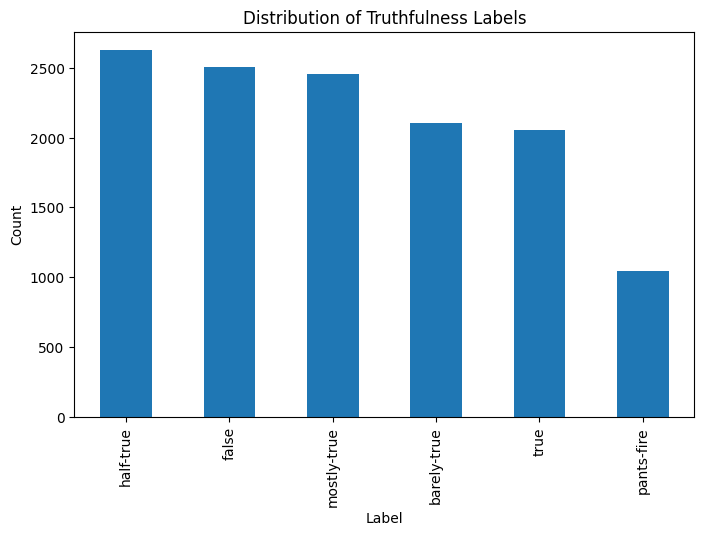

In [48]:
plt.figure(figsize=(8,5))
merged_df["Label"].value_counts().plot(kind="bar")
plt.title("Distribution of Truthfulness Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

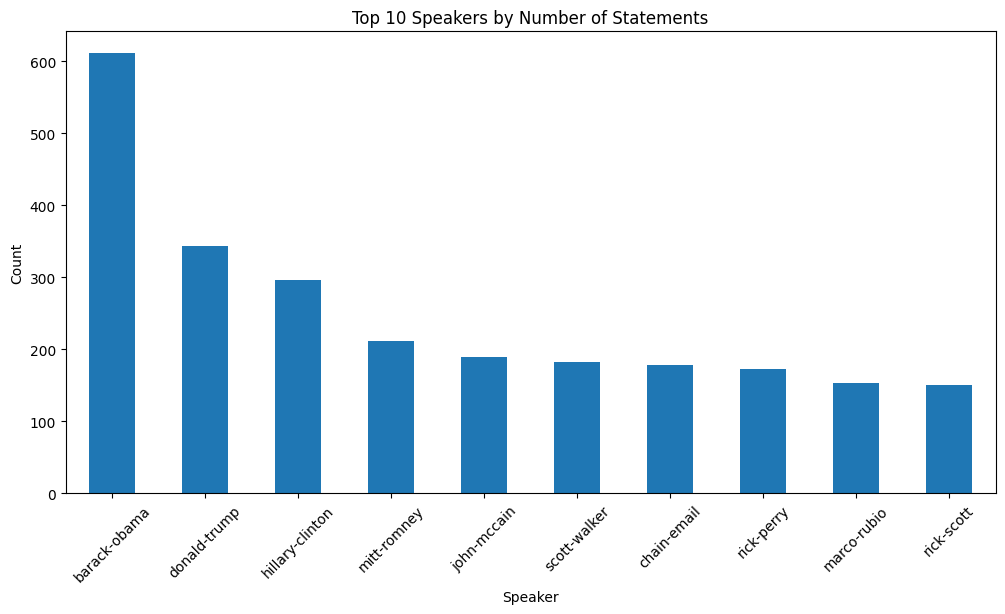

In [49]:
plt.figure(figsize=(12, 6))
merged_df['Speaker'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Speakers by Number of Statements')
plt.xlabel('Speaker')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

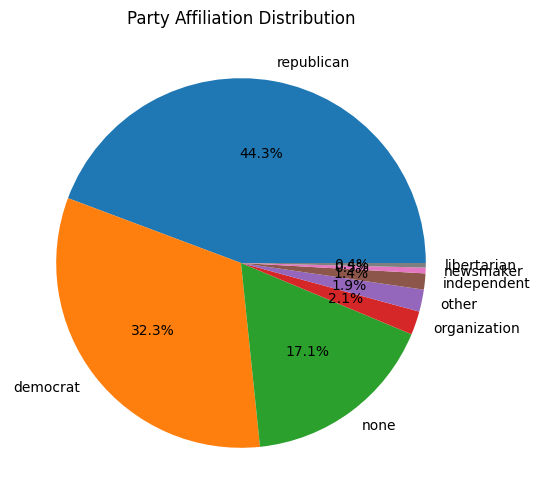

In [105]:
plt.figure(figsize=(8, 6))
merged_df['Party Affiliation'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Party Affiliation Distribution')
plt.ylabel('')
plt.show()

#try to re run it after normalization to 8 categories for a better vision.

In [51]:
merged_df['Party Affiliation'].value_counts()

Party Affiliation
republican                      5665
democrat                        4137
none                            2181
organization                     264
independent                      180
newsmaker                         64
libertarian                       51
journalist                        49
activist                          45
columnist                         44
talk-show-host                    32
state-official                    24
labor-leader                      15
business-leader                   11
tea-party-member                  10
education-official                 3
green                              3
constitution-party                 3
county-commissioner                2
government-body                    2
Moderate                           1
liberal-party-canada               1
ocean-state-tea-party-action       1
democratic-farmer-labor            1
Name: count, dtype: int64

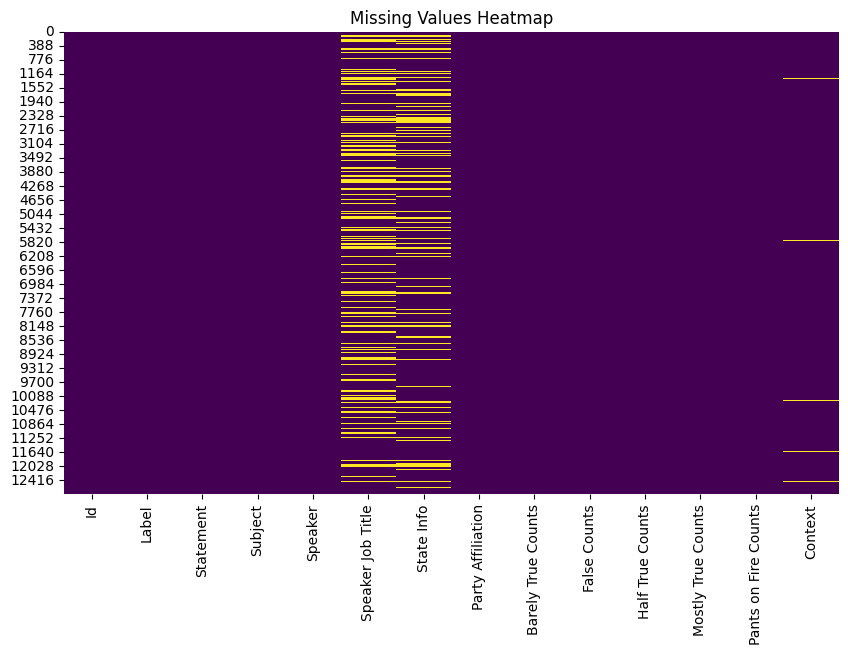

In [52]:
plt.figure(figsize=(10, 6))
sns.heatmap(merged_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


### Data Cleaning , Normalization & Feature Engineering

In [53]:
merged_df.dtypes

Id                       object
Label                    object
Statement                object
Subject                  object
Speaker                  object
Speaker Job Title        object
State Info               object
Party Affiliation        object
Barely True Counts      float64
False Counts            float64
Half True Counts        float64
Mostly True Counts      float64
Pants on Fire Counts    float64
Context                  object
dtype: object

In [54]:
# Convert count columns to integer
count_columns = [
    'Barely True Counts',
    'False Counts',
    'Half True Counts',
    'Mostly True Counts',
    'Pants on Fire Counts'
]

merged_df[count_columns] = merged_df[count_columns].astype('Int64')  # nullable int type

In [55]:
merged_df.dtypes

Id                      object
Label                   object
Statement               object
Subject                 object
Speaker                 object
Speaker Job Title       object
State Info              object
Party Affiliation       object
Barely True Counts       Int64
False Counts             Int64
Half True Counts         Int64
Mostly True Counts       Int64
Pants on Fire Counts     Int64
Context                 object
dtype: object

In [56]:
def clean_text(text):
   # Function to clean and lemmatize text data
    text = text.lower()  # Convert text to lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters and punctuation
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8') # Normalize accented characters (e.g., é -> e)
    text = re.sub(r'\s+', ' ', text).strip()  # Remove unnecessary whitespace
    
    return text

In [57]:
# Apply text cleaning
merged_df['statement_cleaned'] = merged_df['Statement'].apply(clean_text)

# Display the resulting DataFrame
print(merged_df.head())

           Id        Label                                          Statement  \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                              Subject         Speaker     Speaker Job Title  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

  State Info Party Affiliation  Barely

In [58]:
# Map labels to normalized categories
label_mapping = {
    'barely-true': 'barely true',
    'false': 'false',
    'half-true': 'half true',
    'mostly-true': 'mostly true',
    'pants-fire': 'pants on fire',
    'true': 'true'
}

merged_df['Label'] = merged_df['Label'].str.lower().map(label_mapping)

In [59]:
# Check if any labels are invalid after mapping
invalid_labels = merged_df['Label'].isnull().sum()
print(f"Invalid labels after mapping: {invalid_labels}")

Invalid labels after mapping: 0


In [60]:
print("Before:", merged_df.shape)
merged_df = merged_df.dropna(subset=['Subject'])
print("After:", merged_df.shape)


Before: (12791, 15)
After: (12789, 15)


In [61]:
null_values_summary(merged_df)


Null values in each column:
Id                         0
Label                      0
Statement                  0
Subject                    0
Speaker                    0
Speaker Job Title       3566
State Info              2749
Party Affiliation          0
Barely True Counts         0
False Counts               0
Half True Counts           0
Mostly True Counts         0
Pants on Fire Counts       0
Context                  129
statement_cleaned          0
dtype: int64


In [62]:
merged_df['Context'].value_counts().head(10)

Context
a news release       309
an interview         286
a press release      282
a speech             259
a TV ad              222
a tweet              190
a campaign ad        164
a television ad      161
a radio interview    126
a debate             114
Name: count, dtype: int64

In [63]:
#show context missing values
filt_context = merged_df['Context'].isna() == True
merged_df.loc[filt_context]
#SINCE context column isn't essential as the other columns and it has 1% of missing values only 
#we can just replace them with  '<MISSING>'(better than unknown when it comes to modeling)
merged_df.loc[filt_context, 'Context'] = '<MISSING>'

In [64]:
merged_df.isna().sum()

Id                         0
Label                      0
Statement                  0
Subject                    0
Speaker                    0
Speaker Job Title       3566
State Info              2749
Party Affiliation          0
Barely True Counts         0
False Counts               0
Half True Counts           0
Mostly True Counts         0
Pants on Fire Counts       0
Context                    0
statement_cleaned          0
dtype: int64

In [65]:
merged_df['Speaker Job Title'].value_counts()

Speaker Job Title
President                                                                 615
U.S. Senator                                                              595
Governor                                                                  487
President-Elect                                                           343
U.S. senator                                                              328
                                                                         ... 
Executive director of the Ohio Association of Second Harvest Foodbanks      1
Senior adviser to Mitt Romney's presidential campaign                       1
president, Associated Industries of Florida                                 1
Campaign chair of Fair Districts Florida                                    1
promoting approval of financing for Sun Life Stadium                        1
Name: count, Length: 1354, dtype: int64

In [66]:
#func to normalize speaker job title 
def normalize_title(t):
    t = t.lower()
    if t == "<missing>":
        return "missing"

    # politics / government
    if "president" in t: return "executive_president"
    if "senator" in t: return "legislator_senator"
    if "representative" in t or "congress" in t: return "legislator_house"
    if "governor" in t: return "executive_governor"
    if "mayor" in t: return "executive_mayor"
    if "secretary" in t or "minister" in t: return "government_official"

    # media / comms
    if "journalist" in t or "reporter" in t or "anchor" in t or "host" in t:
        return "media"

    # legal
    if "attorney" in t or "lawyer" in t or "judge" in t:
        return "legal"

    # academic
    if "professor" in t or "research" in t or "university" in t:
        return "academic"

    # business
    if "ceo" in t or "founder" in t or "executive" in t or "business" in t:
        return "business"

    # activists / orgs
    if "director" in t or "chair" in t or "president of" in t:
        return "organization_leader"

    return "other"



In [67]:
merged_df['Speaker Job Title'].value_counts()


Speaker Job Title
President                                                                 615
U.S. Senator                                                              595
Governor                                                                  487
President-Elect                                                           343
U.S. senator                                                              328
                                                                         ... 
Executive director of the Ohio Association of Second Harvest Foodbanks      1
Senior adviser to Mitt Romney's presidential campaign                       1
president, Associated Industries of Florida                                 1
Campaign chair of Fair Districts Florida                                    1
promoting approval of financing for Sun Life Stadium                        1
Name: count, Length: 1354, dtype: int64

In [68]:
#Got Problems when normalizing cuz of float values 
#shows float values in Speaker Job Title
mask_float = merged_df["Speaker Job Title"].apply(lambda x: isinstance(x, float))
merged_df.loc[mask_float, "Speaker Job Title"]

3        NaN
4        NaN
6        NaN
8        NaN
13       NaN
        ... 
12777    NaN
12781    NaN
12784    NaN
12785    NaN
12790    NaN
Name: Speaker Job Title, Length: 3566, dtype: object

In [69]:
#Replacing nan with '<MISSING>'
merged_df.fillna({'Speaker Job Title':'<MISSING>'},inplace = True)


In [70]:
merged_df.isna().sum() #0 na speaker job title

Id                         0
Label                      0
Statement                  0
Subject                    0
Speaker                    0
Speaker Job Title          0
State Info              2749
Party Affiliation          0
Barely True Counts         0
False Counts               0
Half True Counts           0
Mostly True Counts         0
Pants on Fire Counts       0
Context                    0
statement_cleaned          0
dtype: int64

In [71]:
merged_df['Speaker Job Category'] = merged_df['Speaker Job Title'].apply(normalize_title) 

In [72]:
merged_df['Speaker Job Category'].value_counts()

Speaker Job Category
missing                3566
other                  1949
legislator_senator     1517
executive_president    1516
legislator_house       1407
executive_governor     1142
business                414
media                   385
legal                   303
organization_leader     216
executive_mayor         201
government_official     103
academic                 70
Name: count, dtype: int64

In [73]:
#now lets go deeply with 'Other' 
group_by_sjc = merged_df.groupby('Speaker Job Category')
other_grp = group_by_sjc.get_group('other')
other_grp[['Speaker Job Title','Speaker Job Category']].value_counts()

#found it still has many titles 

Speaker Job Title                                                                 Speaker Job Category
Social media posting                                                              other                   100
Candidate for U.S. Senate and physician                                           other                    52
House Majority Leader                                                             other                    45
author                                                                            other                    44
consultant                                                                        other                    36
                                                                                                         ... 
Adjunct Senior Fellow for Middle Eastern Studies at Council on Foreign Relations  other                     1
Activist, stay-at-home mom                                                        other                     1
Activist group fo

In [74]:
#map the rest 
#2nd func to normalize
import re

def bucket_title(t):
    t = str(t).strip().lower()
    if t in ["<missing>", "nan", "none"]:
        return "missing"

    # politics / gov (broad)
    if any(k in t for k in [
        "president", "vice president", "president-elect",
        "senator", "u.s. senator", "us senator",
        "representative", "congress", "house majority leader",
        "majority leader", "minority leader", "speaker of the house",
        "governor", "mayor", "secretary", "minister", "commissioner",
        "state rep", "state representative", "state senator",
        "candidate", "campaign"
    ]):
        return "politics_government"

    # media / journalism
    if any(k in t for k in [
        "journalist", "reporter", "anchor", "host", "editor",
        "news", "columnist", "writer", "correspondent",
        "abc", "cnn", "fox", "msnbc"
    ]) or re.search(r"\b(author)\b", t):
        return "media"

    # academic / research / think tank
    if any(k in t for k in [
        "professor", "university", "research", "fellow",
        "council on foreign relations", "think tank", "institute"
    ]):
        return "academic_thinktank"

    # legal
    if any(k in t for k in ["attorney", "lawyer", "judge", "prosecutor"]):
        return "legal"

    # business / professional
    if any(k in t for k in [
        "ceo", "founder", "executive", "consultant",
        "accountant", "manager", "analyst", "entrepreneur"
    ]):
        return "business"

    # activism / NGO / org leader
    if any(k in t for k in [
        "activist", "advocate", "nonprofit", "ngo",
        "executive director", "director", "chair", "campaign chair"
    ]):
        return "activist_ngo"

    # healthcare (optional bucket)
    if any(k in t for k in ["physician", "doctor", "medical", "health"]):
        return "healthcare"

    return "other"


In [75]:
merged_df['Speaker Job Category'].value_counts()


Speaker Job Category
missing                3566
other                  1949
legislator_senator     1517
executive_president    1516
legislator_house       1407
executive_governor     1142
business                414
media                   385
legal                   303
organization_leader     216
executive_mayor         201
government_official     103
academic                 70
Name: count, dtype: int64

In [76]:
#Assuming all values are not null and not duplicated 
merged_df['Id'].value_counts() 
merged_df['Id'].isna().sum()

#updating id structure 
def update_id_structure (Id) :
    Id = Id.split('.')[0]
    return Id
merged_df['Id'] = merged_df['Id'].apply(update_id_structure) 
merged_df['Id']
merged_df['Id'].astype('int64') #assuming all id's now are integers

0         2635
1        10540
2          324
3         1123
4         9028
         ...  
12786     7334
12787     9788
12788    10710
12789     3186
12790     6743
Name: Id, Length: 12789, dtype: int64

In [77]:
merged_df.isna().sum()

Id                         0
Label                      0
Statement                  0
Subject                    0
Speaker                    0
Speaker Job Title          0
State Info              2749
Party Affiliation          0
Barely True Counts         0
False Counts               0
Half True Counts           0
Mostly True Counts         0
Pants on Fire Counts       0
Context                    0
statement_cleaned          0
Speaker Job Category       0
dtype: int64

In [78]:
merged_df['State Info'].value_counts()

State Info
Texas                1260
Florida              1231
Wisconsin             900
New York              829
Illinois              692
                     ... 
PA - Pennsylvania       1
Tex                     1
the United States       1
Rhode Island            1
Georgia                 1
Name: count, Length: 84, dtype: int64

In [79]:
filt_na_state_info = merged_df['State Info'].isna() == True
merged_df.loc[filt_na_state_info]

,Id,Label,Statement,Subject,Speaker,Speaker Job Title,State Info,Party Affiliation,Barely True Counts,False Counts,Half True Counts,Mostly True Counts,Pants on Fire Counts,Context,statement_cleaned,Speaker Job Category
3,1123,false,Health care reform legislation is likely to ma...,health-care,blog-posting,<MISSING>,NaN,none,7,19,3,5,44,a news release,health care reform legislation is likely to ma...,missing
8,5602,half true,"However, it took $19.5 million in Oregon Lotte...",jobs,oregon-lottery,<MISSING>,NaN,organization,0,0,1,0,1,a website,however it took 195 million in oregon lottery ...,missing
13,8616,mostly true,The economy bled $24 billion due to the govern...,"economy,federal-budget,health-care",doonesbury,<MISSING>,NaN,none,0,0,2,4,0,a Doonesbury strip in the Sunday comics,the economy bled 24 billion due to the governm...,missing
17,3863,barely true,"U.S. Rep. Ron Kind, D-Wis., and his fellow Dem...",federal-budget,national-republican-congressional-committee,<MISSING>,NaN,republican,18,9,8,5,8,a news release,us rep ron kind dwis and his fellow democrats ...,missing
21,9867,mostly true,The United States has the highest corporate ta...,"corporations,taxes",eric-bolling,"Co-host on Fox News Channel's ""The Five""",NaN,none,2,1,1,1,0,"a discussion on Fox News' ""The Five""",the united states has the highest corporate ta...,media
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12758,6045,pants on fire,Says Hawaii Gov. Neil Abercrombie made a late-...,obama-birth-certificate,chain-email,<MISSING>,NaN,none,11,43,8,5,105,e-mail messages circulating on the Internet,says hawaii gov neil abercrombie made a lateni...,missing
12777,9241,true,I am the only senator who turned down the stat...,pensions,don-balfour,<MISSING>,NaN,republican,0,0,0,2,0,campaign flier,i am the only senator who turned down the stat...,missing
12781,1005,pants on fire,Obama used $20 million in federal money to emm...,foreign-policy,chain-email,<MISSING>,NaN,none,11,43,8,5,105,a chain e-mail,obama used 20 million in federal money to emmi...,missing
12785,6699,pants on fire,Sen. Bob Menendez voted to enact a new tax on ...,"health-care,housing,income,taxes",menendez-facts,<MISSING>,NaN,none,0,0,0,0,1,a blog,sen bob menendez voted to enact a new tax on t...,missing


In [80]:
#Since State info isnt considered as an important feature for our case then we'll replace NaN values with Unkown .
merged_df.fillna({'State Info':'Unknown'},inplace = True)

In [81]:
merged_df.isna().sum()

Id                      0
Label                   0
Statement               0
Subject                 0
Speaker                 0
Speaker Job Title       0
State Info              0
Party Affiliation       0
Barely True Counts      0
False Counts            0
Half True Counts        0
Mostly True Counts      0
Pants on Fire Counts    0
Context                 0
statement_cleaned       0
Speaker Job Category    0
dtype: int64

In [82]:
#normalazing state info 
merged_df['State Info'] = (
    merged_df['State Info']
    .astype(str)
    .str.normalize('NFKC')
    .str.replace('\xa0', ' ', regex=False)
    .str.strip()
    .str.lower()
)


In [83]:
# pd.set_option('display.max_rows', None)
merged_df['State Info'].value_counts()

State Info
unknown              2752
texas                1260
florida              1237
wisconsin             902
new york              831
                     ... 
tennesse                1
washington dc           1
pa - pennsylvania       1
tex                     1
the united states       1
Name: count, Length: 68, dtype: int64

In [84]:
#replacing 

mapping = {
    # abbreviations / variants
    'tex': 'texas',
    'pa - pennsylvania': 'pennsylvania',
    'washington state': 'washington',

    # DC variants
    'washington, d.c.': 'district of columbia',
    'washington dc': 'district of columbia',
    'washington d.c.': 'district of columbia',

    # typos
    'virgina': 'virginia',
    'virgiia': 'virginia',
    'tennesse': 'tennessee',
    'rhode island': 'rhode island',  # casing fix happens via lower()

    # non-us-states → unknown
    'russia': 'unknown',
    'china': 'unknown',
    'qatar': 'unknown',
    'united kingdom': 'unknown',
    'the united states': 'unknown',
    'atlanta': 'unknown',
    'virginia director, coalition to stop gun violence': 'unknown'
}

merged_df['State Info'] = merged_df['State Info'].replace(mapping)


In [85]:
merged_df['State Info'].value_counts()

State Info
unknown                 2760
texas                   1261
florida                 1237
wisconsin                902
new york                 831
illinois                 695
ohio                     589
georgia                  553
virginia                 517
rhode island             454
oregon                   310
new jersey               305
massachusetts            256
arizona                  228
california               184
district of columbia     174
vermont                  117
pennsylvania             113
new hampshire            108
arkansas                 103
kentucky                  98
tennessee                 89
maryland                  86
delaware                  84
alaska                    81
minnesota                 75
north carolina            72
nevada                    58
indiana                   52
missouri                  49
south carolina            39
new mexico                37
colorado                  33
louisiana                 33
mic

In [86]:
merged_df['Speaker Job Category'].value_counts()

Speaker Job Category
missing                3566
other                  1949
legislator_senator     1517
executive_president    1516
legislator_house       1407
executive_governor     1142
business                414
media                   385
legal                   303
organization_leader     216
executive_mayor         201
government_official     103
academic                 70
Name: count, dtype: int64

In [87]:
#In short feautre Enineering has been applied in 3 feautres (Label,Statement,Party Affiliation)

# Data Transformation



In [88]:
merged_df.head()

,Id,Label,Statement,Subject,Speaker,Speaker Job Title,State Info,Party Affiliation,Barely True Counts,False Counts,Half True Counts,Mostly True Counts,Pants on Fire Counts,Context,statement_cleaned,Speaker Job Category
0,2635,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,texas,republican,0,1,0,0,0,a mailer,says the annies list political group supports ...,legislator_house
1,10540,half true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,virginia,democrat,0,0,1,1,0,a floor speech.,when did the decline of coal start it started ...,other
2,324,mostly true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,illinois,democrat,70,71,160,163,9,Denver,hillary clinton agrees with john mccain by vot...,executive_president
3,1123,false,Health care reform legislation is likely to ma...,health-care,blog-posting,<MISSING>,unknown,none,7,19,3,5,44,a news release,health care reform legislation is likely to ma...,missing
4,9028,half true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,<MISSING>,florida,democrat,15,9,20,19,2,an interview on CNN,the economic turnaround started at the end of ...,missing


## Party Affiliation Transformation

In [89]:
merged_df['Party Affiliation'].value_counts()

Party Affiliation
republican                      5665
democrat                        4137
none                            2181
organization                     264
independent                      180
newsmaker                         64
libertarian                       51
journalist                        49
activist                          45
columnist                         44
talk-show-host                    32
state-official                    24
labor-leader                      15
business-leader                   11
tea-party-member                  10
education-official                 3
green                              3
constitution-party                 3
county-commissioner                2
government-body                    2
Moderate                           1
liberal-party-canada               1
ocean-state-tea-party-action       1
democratic-farmer-labor            1
Name: count, dtype: int64

In [90]:
merged_df.columns

Index(['Id', 'Label', 'Statement', 'Subject', 'Speaker', 'Speaker Job Title',
       'State Info', 'Party Affiliation', 'Barely True Counts', 'False Counts',
       'Half True Counts', 'Mostly True Counts', 'Pants on Fire Counts',
       'Context', 'statement_cleaned', 'Speaker Job Category'],
      dtype='object')

In [91]:
#handling party affiliation outliers 
#all other values with a count <15 will be treated as other 
party_counts = merged_df['Party Affiliation'].value_counts()
filt_to_go = merged_df['Party Affiliation'].map(party_counts) < 50
merged_df.loc[filt_to_go,'Party Affiliation'] = 'other'
merged_df['Party Affiliation'].value_counts()

Party Affiliation
republican      5665
democrat        4137
none            2181
organization     264
other            247
independent      180
newsmaker         64
libertarian       51
Name: count, dtype: int64

In [92]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
)

X_party = ohe.fit_transform(merged_df[['Party Affiliation']])


In [93]:
#inspect 
ohe.get_feature_names_out()
np.array(['Party Affiliation_democrat', 'Party Affiliation_republican',
       'Party Affiliation_none', 'Party Affiliation_organization',
       'Party Affiliation_independent', 'Party Affiliation_newsmaker',
       'Party Affiliation_libertarian', 'Party Affiliation_other'], dtype=object)


X_party_df = pd.DataFrame(
    X_party.toarray(),  # convert sparse to dense
    columns=ohe.get_feature_names_out()
)

X_party_df.head()


,Party Affiliation_democrat,Party Affiliation_independent,Party Affiliation_libertarian,Party Affiliation_newsmaker,Party Affiliation_none,Party Affiliation_organization,Party Affiliation_other,Party Affiliation_republican
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [94]:
#merging transformed party affiliation column to the df 
for i in X_party_df.columns : 
    merged_df[i] = X_party_df[i]
    

## Label Transformation

In [95]:
merged_df['Label'].value_counts()

Label
half true        2627
false            2505
mostly true      2454
barely true      2103
true             2053
pants on fire    1047
Name: count, dtype: int64

In [96]:
#Label
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
merged_df['Label_encoded'] = le.fit_transform(merged_df['Label'])


In [97]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
label_mapping


{'barely true': np.int64(0),
 'false': np.int64(1),
 'half true': np.int64(2),
 'mostly true': np.int64(3),
 'pants on fire': np.int64(4),
 'true': np.int64(5)}

In [98]:
y = merged_df['Label_encoded']
y

0        1
1        2
2        3
3        1
4        2
        ..
12786    2
12787    0
12788    0
12789    0
12790    1
Name: Label_encoded, Length: 12789, dtype: int64

In [99]:
#switching to binary 
merged_df['Label_encoded']= [0 if i in [0,1,4] else 1 for i in merged_df['Label_encoded']] 

In [100]:
merged_df[['Label', 'Label_encoded']].head(10)


,Label,Label_encoded
0,false,0
1,half true,1
2,mostly true,1
3,false,0
4,half true,1
5,true,1
6,barely true,0
7,half true,1
8,half true,1
9,mostly true,1


## Statement Transformation

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),      # VERY IMPORTANT
    min_df=2,
    max_df=0.9,
    stop_words='english',   # sklearn built-in stopwords
    sublinear_tf=True
)


In [102]:
#combining statement with party
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('text', tfidf, 'statement_cleaned'),
        ('party', OneHotEncoder(handle_unknown='ignore'), ['Party Affiliation_democrat', 'Party Affiliation_independent',
       'Party Affiliation_libertarian', 'Party Affiliation_newsmaker',
       'Party Affiliation_none', 'Party Affiliation_organization',
       'Party Affiliation_other', 'Party Affiliation_republican'])
    ]
)


# Modeling

## RandomForestClassifier and LogisticRegression

In [103]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])


In [104]:
from sklearn.model_selection import train_test_split


X = merged_df[['statement_cleaned','Party Affiliation_democrat', 'Party Affiliation_independent',
       'Party Affiliation_libertarian', 'Party Affiliation_newsmaker',
       'Party Affiliation_none', 'Party Affiliation_organization',
       'Party Affiliation_other', 'Party Affiliation_republican']]

y = merged_df['Label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2
    stratify=y,
    random_state=42
)


SyntaxError: invalid syntax. Perhaps you forgot a comma? (1978924399.py, line 13)

In [ ]:
pipeline.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import classification_report

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred)) 


## XGboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- 1. Define features and target ---
# Example: replace 'Label_encoded' with your target column
target = 'Label_encoded'

text_feature = 'statement_cleaned'
numeric_features = ['Barely True Counts', 'False Counts', 'Half True Counts', 
                    'Mostly True Counts', 'Pants on Fire Counts']
categorical_features = ['Party Affiliation', 'Speaker Job Category']  # add more if useful

X = merged_df[text_feature].to_frame()  # keep text column separate
X[numeric_features + categorical_features] = merged_df[numeric_features + categorical_features]
y = merged_df[target]

# --- 2. Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Define transformers ---
# TF-IDF for text
tfidf = TfidfVectorizer(
    max_df=0.9,
    min_df=2,
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english',
    sublinear_tf=True
)

# One-hot for categorical
onehot = OneHotEncoder(handle_unknown='ignore')

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('text', tfidf, text_feature),
        ('cat', onehot, categorical_features)
        # Numeric features will pass through automatically
    ],
    remainder='passthrough'  # numeric features
)

# --- 4. XGBoost classifier ---
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),  # handles imbalance
    random_state=42
)

# --- 5. Build pipeline ---
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_clf)
])

# --- 6. Train ---
pipeline.fit(X_train, y_train)

# --- 7. Evaluate ---
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
#manual testing 
X_test

In [ ]:
a = X_test.iloc[0]
y_pred = pipeline.predict(X_test)
y_pred[1]

In [ ]:
merged_df.shape